In [2]:
pip install dagshub

In [3]:
import pandas as pd
from tensorflow.keras import Sequential, callbacks
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, InputLayer, Activation
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import optuna
import mlflow
import dagshub

In [7]:
train_df.columns

Index(['Unnamed: 0', 'ord_cat__traffic', 'ord_cat__distance_type',
       'ord_cat__order_time_of_day', 'nom_cat__weather_fog',
       'nom_cat__weather_sandstorms', 'nom_cat__weather_stormy',
       'nom_cat__weather_sunny', 'nom_cat__weather_windy',
       'nom_cat__order_type_drinks', 'nom_cat__order_type_meal',
       'nom_cat__order_type_snack', 'nom_cat__vehicle_type_motorcycle',
       'nom_cat__vehicle_type_scooter', 'nom_cat__festival_yes',
       'nom_cat__city_type_semi-urban', 'nom_cat__city_type_urban', 'num__age',
       'num__ratings', 'num__pickup_time', 'num__distance',
       'remainder__condition', 'remainder__multi_deliveries',
       'remainder__order_month', 'remainder__is_weekend', 'time'],
      dtype='object')

In [8]:
train_df = pd.read_csv("/content/train_df.csv")
test_df = pd.read_csv("/content/test_df.csv")

X_train = train_df.drop(columns=["time"])
X_test = test_df.drop(columns=["time"])

y_train = train_df["time"]
y_test = test_df["time"]

In [9]:
def objective(trial):

  n_layers = trial.suggest_int("layers", 1, 5)
  units = trial.suggest_int("units", 64, 512,log=True)
  dropout = trial.suggest_float("dropout", 0.0, 0.5)
  lr = trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True)

  model = Sequential()

  model.add(InputLayer(shape=(X_train.shape[1], )))

  for _ in range(n_layers):

      model.add(Dense(units, use_bias=False))
      model.add(BatchNormalization())
      model.add(Activation("relu"))
      model.add(Dropout(dropout))

  model.add(Dense(1))

  model.compile(optimizer=Adam(learning_rate=lr),
                loss="mae")

  callback = callbacks.EarlyStopping(
      patience=10, restore_best_weights=True
  )

  model.fit(X_train, y_train, validation_data=(X_test, y_test),
            epochs=50, batch_size=128, callbacks=callback)

  y_pred = model.predict(X_test)

  mae = mean_absolute_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)

  trial.set_user_attr("r2_score", r2)

  return mae

In [10]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

[I 2026-02-20 07:05:47,899] A new study created in memory with name: no-name-35b041a6-b12b-4bde-abe4-c0fd4af01266


Epoch 1/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.7627 - val_loss: 0.6032
Epoch 2/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.4811 - val_loss: 0.4316
Epoch 3/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.4492 - val_loss: 0.4372
Epoch 4/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.4336 - val_loss: 0.3796
Epoch 5/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.4177 - val_loss: 0.3816
Epoch 6/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.4118 - val_loss: 0.3727
Epoch 7/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.4043 - val_loss: 0.3659
Epoch 8/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.3956 - val_loss: 0.3686
Epoch 9/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.3994 - val_loss: 0.3674
Epoch 10/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.3922 - val_loss: 0.3920
Epoch 11/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.3869 - val_loss: 0.3613
Epoch 12/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 

[I 2026-02-20 07:08:54,030] Trial 0 finished with value: 0.3280144078025935 and parameters: {'layers': 5, 'units': 243, 'dropout': 0.37179157968389726, 'learning_rate': 0.00523915435107235}. Best is trial 0 with value: 0.3280144078025935.


Epoch 1/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5806 - val_loss: 0.4611
Epoch 2/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4464 - val_loss: 0.4342
Epoch 3/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4386 - val_loss: 0.4196
Epoch 4/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4378 - val_loss: 0.4208
Epoch 5/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4224 - val_loss: 0.4235
Epoch 6/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4241 - val_loss: 0.4085
Epoch 7/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4150 - val_loss: 0.4850
Epoch 8/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4147 - val_loss: 0.4273
Epoch 9/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4145 - val_loss: 0.4726
Epoch 10/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4104 - val_loss: 0.3942
Epoch 11/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4147 - val_loss: 0.4142
Epoch 12/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

[I 2026-02-20 07:09:38,354] Trial 1 finished with value: 0.37792673570922225 and parameters: {'layers': 1, 'units': 161, 'dropout': 0.11456047930035979, 'learning_rate': 0.013592583903705959}. Best is trial 0 with value: 0.3280144078025935.


...

Epoch 1/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6384 - val_loss: 0.5802
Epoch 2/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4701 - val_loss: 0.4448
Epoch 3/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.4549 - val_loss: 0.4329
Epoch 4/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4439 - val_loss: 0.4272
Epoch 5/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4320 - val_loss: 0.4102
Epoch 6/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4280 - val_loss: 0.4942
Epoch 7/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4206 - val_loss: 0.4213
Epoch 8/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4200 - val_loss: 0.4114
Epoch 9/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4155 - val_loss: 0.3939
Epoch 10/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4132 - val_loss: 0.3941
Epoch 11/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4078 - val_loss: 0.3967
Epoch 12/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

[I 2026-02-20 07:15:50,563] Trial 3 finished with value: 0.3688845373003805 and parameters: {'layers': 1, 'units': 484, 'dropout': 0.234460359943439, 'learning_rate': 0.0037936033279769156}. Best is trial 0 with value: 0.3280144078025935.


Epoch 1/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.6838 - val_loss: 0.4986
Epoch 2/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4613 - val_loss: 0.4112
Epoch 3/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.4332 - val_loss: 0.3894
Epoch 4/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.4204 - val_loss: 0.3948
Epoch 5/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4040 - val_loss: 0.3758
Epoch 6/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3974 - val_loss: 0.3640
Epoch 7/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3908 - val_loss: 0.3634
Epoch 8/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3863 - val_loss: 0.3530
Epoch 9/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3795 - val_loss: 0.3612
Epoch 10/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3721 - val_loss: 0.3670
Epoch 11/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.3726 - val_loss: 0.3470
Epoch 12/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step

[W 2026-02-20 07:16:51,042] Trial 4 failed with parameters: {'layers': 3, 'units': 142, 'dropout': 0.1939823516587259, 'learning_rate': 0.002635264767732503} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipython-input-3869980846.py", line 28, in objective
    model.fit(X_train, y_train, validation_data=(X_test, y_test),
  File "/usr/local/lib/python3.12/dist-packages/keras/src/utils/traceback_utils.py", line 117, in error_handler
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py", line 377, in fit
    logs = self.train_function(iterator)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py", li

KeyboardInterrupt: 

In [11]:
import json

# best_params = study.best_params
best_params = {"layers": 5, "units": 172, "dropout": 0.12254773493518387,
               "learning_rate": 0.0022750653756536013}

# with open("/content/best_params.json", "r") as file:
#     best_params = json.load(file)

n_layers = best_params["layers"]
units = best_params["units"]
dropout = best_params["dropout"]
lr = best_params["learning_rate"]

model = Sequential()

model.add(InputLayer(shape=(X_train.shape[1], )))

for _ in range(n_layers):

    model.add(Dense(units, use_bias=False))
    model.add(BatchNormalization())
    model.add(Activation("relu"))
    model.add(Dropout(dropout))

model.add(Dense(1))

model.compile(optimizer=Adam(learning_rate=lr),
              loss="mae")

callback = callbacks.EarlyStopping(
    patience=10, restore_best_weights=True
)

history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
            epochs=500, batch_size=128, callbacks=callback)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mae, r2

Epoch 1/500
231/231 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.6693 - val_loss: 0.4940
Epoch 2/500
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.4510 - val_loss: 0.4172
Epoch 3/500
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.4164 - val_loss: 0.3752
Epoch 4/500
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.4015 - val_loss: 0.3790
Epoch 5/500
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.3876 - val_loss: 0.3748
Epoch 6/500
231/231 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.3810 - val_loss: 0.3510
Epoch 7/500
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.3725 - val_loss: 0.3595
Epoch 8/500
231/231 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.3717 - val_loss: 0.3488
Epoch 9/500
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.3680 - val_loss: 0.3579
Epoch 10/500
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.3626 - val_loss: 0.3453
Epoch 11/500
231/231 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.3556 - val_loss: 0.3490
Epoch 12/500
231/231 ━━━━━━━━━

(0.32440611170651057, 0.8303229775916787)

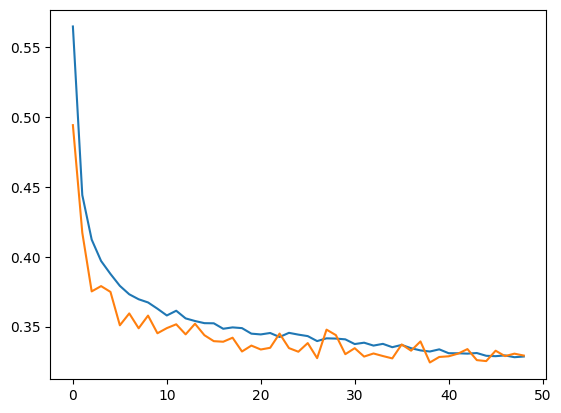

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label ="loss")
plt.plot(history.history["val_loss"], label ="val_loss")

plt.show()

In [ ]:
import json

with open("best_params.json", "w") as file:

  json.dump(study.best_params, file, indent=4)

In [15]:
mlflow.set_tracking_uri("https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow")

dagshub.init(repo_owner='PriyanshuMewal', repo_name='delivery-time-prediction', mlflow=True)

mlflow.set_experiment("Experiment 4: Model Selection Without Missing Values")


Initialized MLflow to track repo "PriyanshuMewal/delivery-time-prediction"

Repository PriyanshuMewal/delivery-time-prediction initialized!

<Experiment: artifact_location='mlflow-artifacts:/0159417f09e1476798193b9381e1c2c4', creation_time=1771566150176, experiment_id='4', last_update_time=1771566150176, lifecycle_stage='active', name='Experiment 4: Model Selection Without Missing Values', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [16]:
with mlflow.start_run(run_name="ANN"):

  # log parameters:
  parameters = {"model": "ANN", "imputation": "droped"}

  parameters.update(best_params)
  mlflow.log_params(best_params)

  # log metrics:
  mlflow.log_metric("mean_absolute_error", mae)
  mlflow.log_metric("r2_score", r2)

  # log model:
  # signature = sklearn.models.infer_signature(X_test, y_pred)
  # mlflow.sklearn.log_model(model, signature=signature)

  # log dataset:
  # mlflow.log_artifact("/content/test_df.csv")
  # mlflow.log_artifact("/content/train_df.csv")


🏃 View run ANN at: https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow/#/experiments/4/runs/f813feaf792e452e807763afd424e1b3
🧪 View experiment at: https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow/#/experiments/4
